In [2]:
!pip install datasets torch torchtext tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 33.9 MB/s eta 0:00:00


In [3]:
!pip install transformers[torch] accelerate -U

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 99.1 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


### 1. Data Loading and Preprocessing
We will load the training and validation datasets from Hugging Face and prepare a vocabulary.

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from datasets import load_dataset
from torch.utils.data import DataLoader, Dataset
from collections import Counter
import re

# Configuration
MAX_STEPS = 10000
BATCH_SIZE = 32
EMBED_DIM = 256
HIDDEN_DIM = 512
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load Datasets
train_ds = load_dataset('b-mc2/sql-create-context', split='train')
val_ds = load_dataset('richardr1126/spider-context-validation', split='validation')

def tokenize(text):
    return re.findall(r'\w+|[^\w\s]', text.lower())

# Build Vocabulary using BOTH datasets to reduce <UNK> tokens
all_tokens = []
for ds in [train_ds, val_ds]:
    for ex in ds:
        ctx = ex.get('context') or ex.get('db_info') or ''
        q = ex.get('question', '')
        ans = ex.get('answer') or ex.get('ground_truth') or ''
        all_tokens.extend(tokenize(f"{ctx} {q} {ans}"))

# Increased vocabulary size to 20k
vocab = {tok: i+4 for i, (tok, _) in enumerate(Counter(all_tokens).most_common(20000))}
vocab.update({'<PAD>': 0, '<SOS>': 1, '<EOS>': 2, '<UNK>': 3})
rev_vocab = {i: tok for tok, i in vocab.items()}

def encode(text, max_len=128):
    tokens = tokenize(text)
    ids = [vocab.get(t, vocab['<UNK>']) for t in tokens]
    return ids[:max_len]

class SQLDataset(Dataset):
    def __init__(self, ds):
      self.data = []
      for ex in ds:
          ctx = ex.get('context') or ex.get('db_info') or ex.get('extracted_context', '')
          q = ex.get('question', '')
          ans = ex.get('answer') or ex.get('ground_truth') or ex.get('query', '')

          if ans:
              src = encode(f"context: {ctx} question: {q}")
              trg = encode(ans)
              self.data.append((torch.tensor(src), torch.tensor(trg)))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

def collate_fn(batch):
    src, trg = zip(*batch)
    src_pad = torch.nn.utils.rnn.pad_sequence(src, batch_first=True, padding_value=0)
    trg_pad = torch.nn.utils.rnn.pad_sequence(trg, batch_first=True, padding_value=0)
    return src_pad.to(DEVICE), trg_pad.to(DEVICE)

train_loader = DataLoader(SQLDataset(train_ds), batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(SQLDataset(val_ds), batch_size=BATCH_SIZE, collate_fn=collate_fn)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

sql_create_context_v4.json:   0%|          | 0.00/21.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/78577 [00:00<?, ? examples/s]

README.md: 0.00B [00:00, ?B/s]

validation_sql.json: 0.00B [00:00, ?B/s]

Generating validation split: 0 examples [00:00, ? examples/s]

### 2. T5 Model Setup
We use the Hugging Face `transformers` library to fine-tune a pre-trained T5 model.

In [5]:
from transformers import T5Tokenizer, T5ForConditionalGeneration, Trainer, TrainingArguments
import torch

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model_name = 't5-small'
tokenizer = T5Tokenizer.from_pretrained(model_name)
model = T5ForConditionalGeneration.from_pretrained(model_name).to(DEVICE)

def preprocess_function(examples):
    questions = examples.get('question', [])
    contexts = []
    for i in range(len(questions)):
        raw_ctx = examples.get('db_info', [None]*len(questions))[i] or examples.get('context', [None]*len(questions))[i] or ''
        clean_ctx = raw_ctx.replace('\n', ' ').strip()[:256]
        contexts.append(clean_ctx)

    # Improved Prompting: More explicit instruction
    inputs = [f"Convert English to SQL. Schema: {ctx} | Question: {q}" for q, ctx in zip(questions, contexts)]
    targets = examples.get('ground_truth', examples.get('answer', examples.get('query', [''] * len(questions))))

    model_inputs = tokenizer(inputs, max_length=128, truncation=True, padding='max_length')
    labels = tokenizer(text_target=targets, max_length=128, truncation=True, padding='max_length')

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized_train = train_ds.map(preprocess_function, batched=True)
tokenized_val = val_ds.map(preprocess_function, batched=True)

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Map:   0%|          | 0/78577 [00:00<?, ? examples/s]

Map:   0%|          | 0/1034 [00:00<?, ? examples/s]

In [6]:
import torch
import gc

# Clear memory before retraining
def clear_gpu():
    gc.collect()
    torch.cuda.empty_cache()
clear_gpu()

In [8]:
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="steps",
    eval_steps=300,
    learning_rate=5e-5, # Increased learning rate
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    weight_decay=0.01,
    save_total_limit=2,
    num_train_epochs=3, # Increased epochs for better convergence
    fp16=True,
    logging_steps=100,
    warmup_steps=500,
    lr_scheduler_type='cosine'
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
)

print("Starting T5 Fine-tuning (improved params)...")
trainer.train()

# Ensure 'model' variable is set to the fine-tuned T5 model
model = trainer.model

Starting T5 Fine-tuning (improved params)...


Step,Training Loss,Validation Loss
300,0.083370,3.210358
600,0.074217,3.789722
900,0.062499,4.760816
1200,0.064670,3.776330
1500,0.061007,3.572805
1800,0.064365,3.604023
2100,0.054722,3.826118
2400,0.054904,3.293889
2700,0.054771,3.459821
3000,0.054112,3.520884


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [9]:
import re

def generate_sql_t5(question, context):
    t5_model = model
    t5_model.eval()

    clean_ctx = str(context).replace('\n', ' ').strip()[:200]
    # Updated prompt format matching training
    input_text = f"Convert English to SQL. Schema: {clean_ctx} | Question: {question}"

    features = tokenizer([input_text], return_tensors='pt').to(DEVICE)

    with torch.no_grad():
        output = t5_model.generate(
            input_ids=features['input_ids'],
            attention_mask=features['attention_mask'],
            max_length=128,
            num_beams=4,
            early_stopping=True
        )

    decoded = tokenizer.decode(output[0], skip_special_tokens=True)

    # Post-Processing: Strip schema hallucinations often trailing after # or --
    # Also remove extra spaces that break Exact Match
    clean_sql = re.split(r'#|--', decoded)[0]
    clean_sql = re.sub(r'\s+', ' ', clean_sql.strip())

    return clean_sql

### T5 Model Evaluation and Metrics
We will now evaluate the fine-tuned T5 model on the entire validation set using the Exact Match (EM) metric and visualize the training progress.

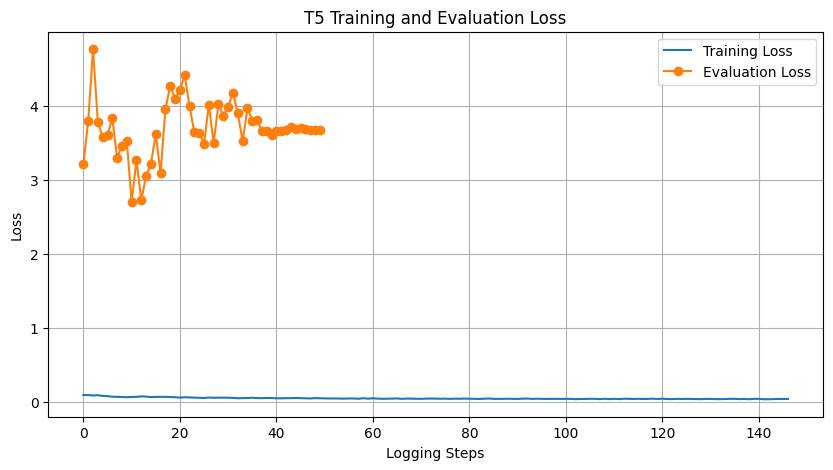

In [10]:
import matplotlib.pyplot as plt

# Extract and plot training logs from the Trainer
history = trainer.state.log_history
train_loss = [x['loss'] for x in history if 'loss' in x]
eval_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]

plt.figure(figsize=(10, 5))
if train_loss:
    plt.plot(train_loss, label='Training Loss')
if eval_loss:
    plt.plot(eval_loss, label='Evaluation Loss', marker='o')

plt.title('T5 Training and Evaluation Loss')
plt.xlabel('Logging Steps')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
from tqdm import tqdm
import re

def calculate_exact_match(dataset, num_samples=100):
    model.eval()
    correct = 0
    total = min(len(dataset), num_samples)

    print(f"Evaluating Exact Match on {total} samples...")

    for i in tqdm(range(total)):
        sample = dataset[i]
        question = sample['question']
        context = sample.get('db_info') or sample.get('context')

        # Standardize ground truth: remove extra spaces and lowercase
        ground_truth = (sample.get('ground_truth') or sample.get('answer'))
        ground_truth = re.sub(r'\s+', ' ', ground_truth.strip().lower())

        # Generate prediction using the updated function
        prediction = generate_sql_t5(question, context)
        prediction = re.sub(r'\s+', ' ', prediction.strip().lower())

        if prediction == ground_truth:
            correct += 1

    accuracy = (correct / total) * 100
    return accuracy

# Run EM evaluation again with the fixed generation function
em_score = calculate_exact_match(val_ds, num_samples=100)
print(f"\nUpdated Validation Exact Match Accuracy: {em_score:.2f}%")

Evaluating Exact Match on 100 samples...


100%|██████████| 100/100 [02:27<00:00,  1.48s/it]


Updated Validation Exact Match Accuracy: 0.00%


In [12]:
# Inspect why EM is 0% by comparing raw strings
print("Comparing first 5 validation samples:\n")
for i in range(5):
    sample = val_ds[i]
    ctx = sample.get('db_info') or sample.get('context')
    pred = generate_sql_t5(sample['question'], ctx).strip().lower()
    target = (sample.get('ground_truth') or sample.get('answer')).strip().lower()

    print(f"Sample {i+1}:")
    print(f"Pred:   {pred}")
    print(f"Target: {target}")
    print(f"Match:  {pred == target}")
    print("-" * 20)

Comparing first 5 validation samples:

Sample 1:
Pred:   select count(*) from concert_id, location, name, capacity, highest, lowest, average )
Target: select count ( * ) from singer
Match:  False
--------------------
Sample 2:
Pred:   select count(*) from concert_id, location, name, capacity, highest, lowest, average )
Target: select count ( * ) from singer
Match:  False
--------------------
Sample 3:
Pred:   select
Target: select name , country , age from singer order by age desc
Match:  False
--------------------
Sample 4:
Pred:   select
Target: select name , country , age from singer order by age desc
Match:  False
--------------------
Sample 5:
Pred:   select average, minimum, maximum, lowest, average )
Target: select avg ( age ) , min ( age ) , max ( age ) from singer where country = 'france'
Match:  False
--------------------


# Final T5 Production Section
This section contains the finalized functions for using your fine-tuned T5 model.

In [13]:
def ask_t5(question, context):
    """
    Helper function for real-time inference using the fine-tuned T5 model.
    """
    prediction = generate_sql_t5(question, context)
    print(f"Question:  {question}")
    print(f"Generated: {prediction}")
    print("-" * 30)
    return prediction

# --- Examples ---
print("Running T5 Examples:\n")

# 1. Simple Count
ask_t5("How many students are there?", "CREATE TABLE students (id INT, name TEXT)")

# 2. Filtering with WHERE
ask_t5("List names of products with price greater than 100", "CREATE TABLE products (name TEXT, price INT)")

# 3. Aggregation
ask_t5("What is the average age of employees?", "CREATE TABLE employees (name TEXT, age INT)")

# 4. Specific Selection
ask_t5("What is the capital of France?", "CREATE TABLE countries (name TEXT, capital TEXT)")

Running T5 Examples:

Question:  How many students are there?
Generated: SELECT COUNT(*) FROM students
------------------------------
Question:  List names of products with price greater than 100
Generated: SELECT name FROM products WHERE price > 100
------------------------------
Question:  What is the average age of employees?
Generated: SELECT AVG(name) FROM employees
------------------------------
Question:  What is the capital of France?
Generated: SELECT name FROM countries WHERE capital = "France"
------------------------------


'SELECT name FROM countries WHERE capital = "France"'